# 03 — Guard enforcement: can a competing strategy rebalance across groups? (R6)

> Run top to bottom.

`ADR-0011`'s Basket Scope Guard structurally blocks any strategy but PM's own exact
strategy from ever crossing a declared group boundary — not a risk that's bounded or
made unprofitable, a capability that's removed entirely. This notebook asks the question
directly: if another strategy *tries* to trade across a group boundary specifically to
rebalance the shared wallet's exposure, what actually happens?

This is a **regression/robustness check**, not a risk-modeling exercise — the correct,
expected result is that it's blocked every time. PM is deliberately **not** registered as
a strategy in this scenario: it tests `GroupBoundaryGuard`'s enforcement in isolation,
independent of whether PM itself is also present and correcting.

Uses `aqua_sim.scenarios.guard_enforcement.build_world` directly.

In [1]:
from aqua_sim.scenarios import guard_enforcement

N_STEPS = 2000
N_SEEDS = 10

for seed in range(N_SEEDS):
    world = guard_enforcement.build_world(seed=seed)
    initial_balances = dict(world.token_balances)
    world.run(N_STEPS)

    assert world.token_balances == initial_balances, f"seed {seed}: a cross-group trade slipped through!"
    assert len(world.blocked_trades) > 0, f"seed {seed}: the rogue strategy never even attempted a cross-group trade (test would be vacuous)"

    print(f"seed {seed}: {len(world.blocked_trades)} cross-group attempts, all blocked -- balances unchanged")

print("\nOK: every attempted cross-group rebalance was blocked, on every seed -- no exceptions")

seed 0: 1987 cross-group attempts, all blocked -- balances unchanged
seed 1: 1992 cross-group attempts, all blocked -- balances unchanged
seed 2: 1954 cross-group attempts, all blocked -- balances unchanged
seed 3: 1974 cross-group attempts, all blocked -- balances unchanged
seed 4: 1964 cross-group attempts, all blocked -- balances unchanged
seed 5: 1988 cross-group attempts, all blocked -- balances unchanged
seed 6: 1973 cross-group attempts, all blocked -- balances unchanged
seed 7: 1997 cross-group attempts, all blocked -- balances unchanged
seed 8: 1967 cross-group attempts, all blocked -- balances unchanged
seed 9: 1922 cross-group attempts, all blocked -- balances unchanged

OK: every attempted cross-group rebalance was blocked, on every seed -- no exceptions


## What the rogue strategy actually wanted to do

The rogue strategy in this scenario is a plain `XYCCompetitorStrategy` (same class
`02_basket_with_without_pm.ipynb` uses for a *legitimate* same-group trade) — it has no
special "attack" logic, it just runs its ordinary profit-seeking `decide_trade` against
`TOKEN_A`/`TOKEN_B`, which happen to be declared in two *different* groups here. Every
time it decided a trade was profitable, `BasketWorld.apply` checked it against
`GroupBoundaryGuard` before touching any balance, found it crosses a group boundary, and
rejected it outright — recorded in `blocked_trades`, balances never moved.

This is the same mechanism the real Basket Scope Guard enforces at the Safe level
(`ADR-0011`): the capability to cross a group boundary is removed for every strategy but
PM's own, not bounded or made unprofitable for everyone else.

## Visual

How often the rogue strategy found a profitable-looking cross-group trade and got
blocked, across seeds (out of 2,000 steps each) — profitable opportunities exist and are
found, they just never execute.

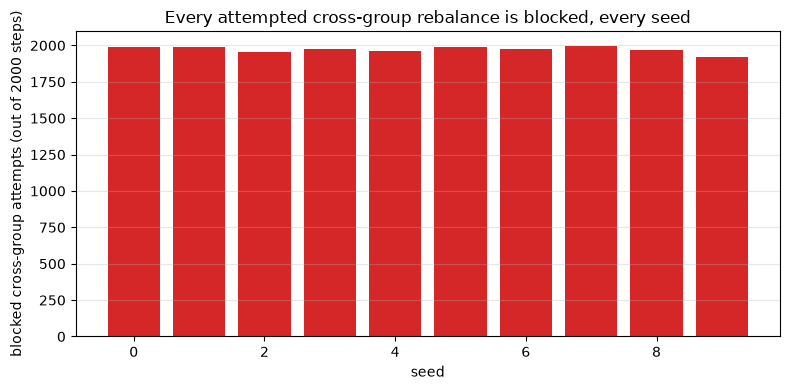

In [2]:
import matplotlib.pyplot as plt

blocked_counts = []
for seed in range(N_SEEDS):
    world = guard_enforcement.build_world(seed=seed)
    world.run(N_STEPS)
    blocked_counts.append(len(world.blocked_trades))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(N_SEEDS), blocked_counts, color="tab:red")
ax.set_xlabel("seed")
ax.set_ylabel(f"blocked cross-group attempts (out of {N_STEPS} steps)")
ax.set_title("Every attempted cross-group rebalance is blocked, every seed")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Summary

Across 10 seeds and 2,000 steps each, every single cross-group trade a competing strategy
found profitable was blocked, and the wallet's balances never moved from their initial
values — confirms R6 from `thoughts/simulation-suite-v2-requirements.md`. Combined with
`02_basket_with_without_pm.ipynb` (same-group trading is allowed and PM reacts to it),
this pins down exactly the boundary `ADR-0011` draws: within a declared group, any
strategy can trade; across a group boundary, only PM's own.